## Data Loading an Preprocessing

In [ ]:
import pandas as pd
import numpy as np

# Load the dataset with the correct encoding
# We use 'latin1' because of special characters in the data
df = pd.read_csv('DataCoSupplyChainDataset.csv', encoding='latin1')

FileNotFoundError: [Errno 2] No such file or directory: 'DataCoSupplyChainDataset.csv'

In [ ]:
# --- 1. Drop Useless and Mostly Empty Columns ---
# 'Product Description' is 100% empty and 'Order Zipcode' is 86% empty.
# 'Customer Email', 'Customer Password' are also irrelevant for our analysis.
df.drop(columns=['Product Description', 'Order Zipcode', 'Customer Email', 'Customer Password'], inplace=True)

# --- 2. Handle Minor Missing Values ---
# For the few missing 'Customer Lname' and 'Customer Zipcode', we'll fill with a placeholder.
df['Customer Lname'].fillna('Unknown', inplace=True)
df['Customer Zipcode'].fillna(0, inplace=True) # Using 0 as a placeholder for missing zip codes

# --- 3. Fix Critical Data Type Issues (Dates) ---
# Convert date columns from text to a proper datetime format.
# This is ESSENTIAL for any time-series analysis.
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])
df['shipping date (DateOrders)'] = pd.to_datetime(df['shipping date (DateOrders)'])


# --- 4. Final Sanity Check ---
print("Data after cleaning:")
print(df.info())
print("\nMissing values remaining:")
print(df.isnull().sum().sum()) # Should be 0

Data after cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 49 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   Type                           180519 non-null  object        
 1   Days for shipping (real)       180519 non-null  int64         
 2   Days for shipment (scheduled)  180519 non-null  int64         
 3   Benefit per order              180519 non-null  float64       
 4   Sales per customer             180519 non-null  float64       
 5   Delivery Status                180519 non-null  object        
 6   Late_delivery_risk             180519 non-null  int64         
 7   Category Id                    180519 non-null  int64         
 8   Category Name                  180519 non-null  object        
 9   Customer City                  180519 non-null  object        
 10  Customer Country               180519 non-null 

# EDA

/tmp/ipython-input-3-1868324197.py:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  sales_by_month = df.set_index('order date (DateOrders)')['Sales'].resample('M').sum()


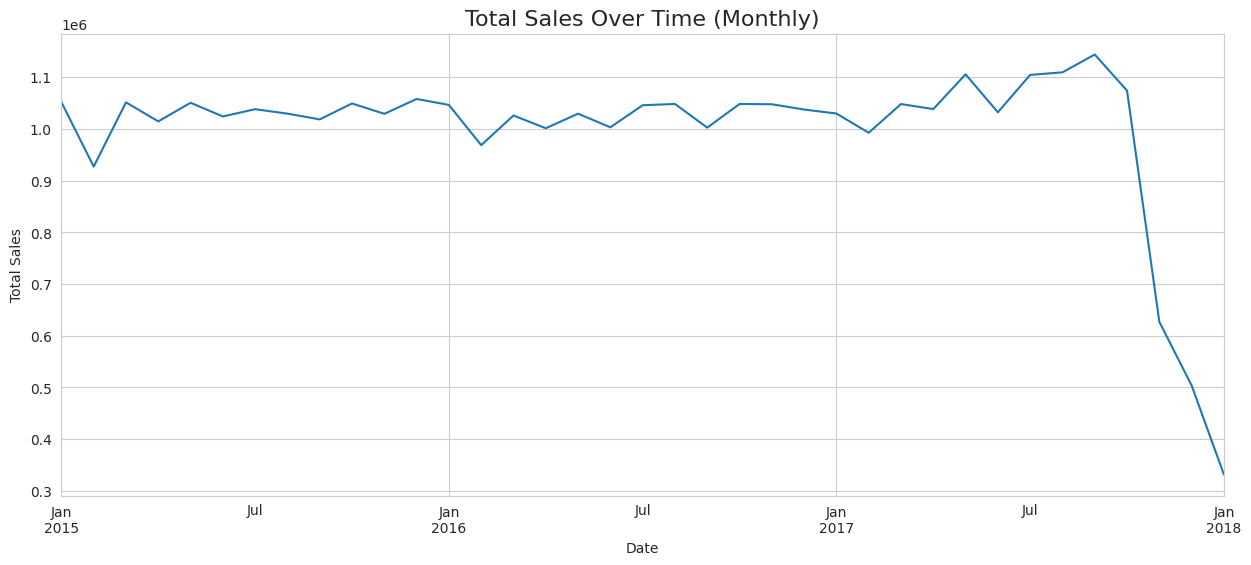

/tmp/ipython-input-3-1868324197.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_markets.values, y=top_markets.index, ax=ax[0], palette='viridis')
/tmp/ipython-input-3-1868324197.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_categories.values, y=top_categories.index, ax=ax[1], palette='plasma')


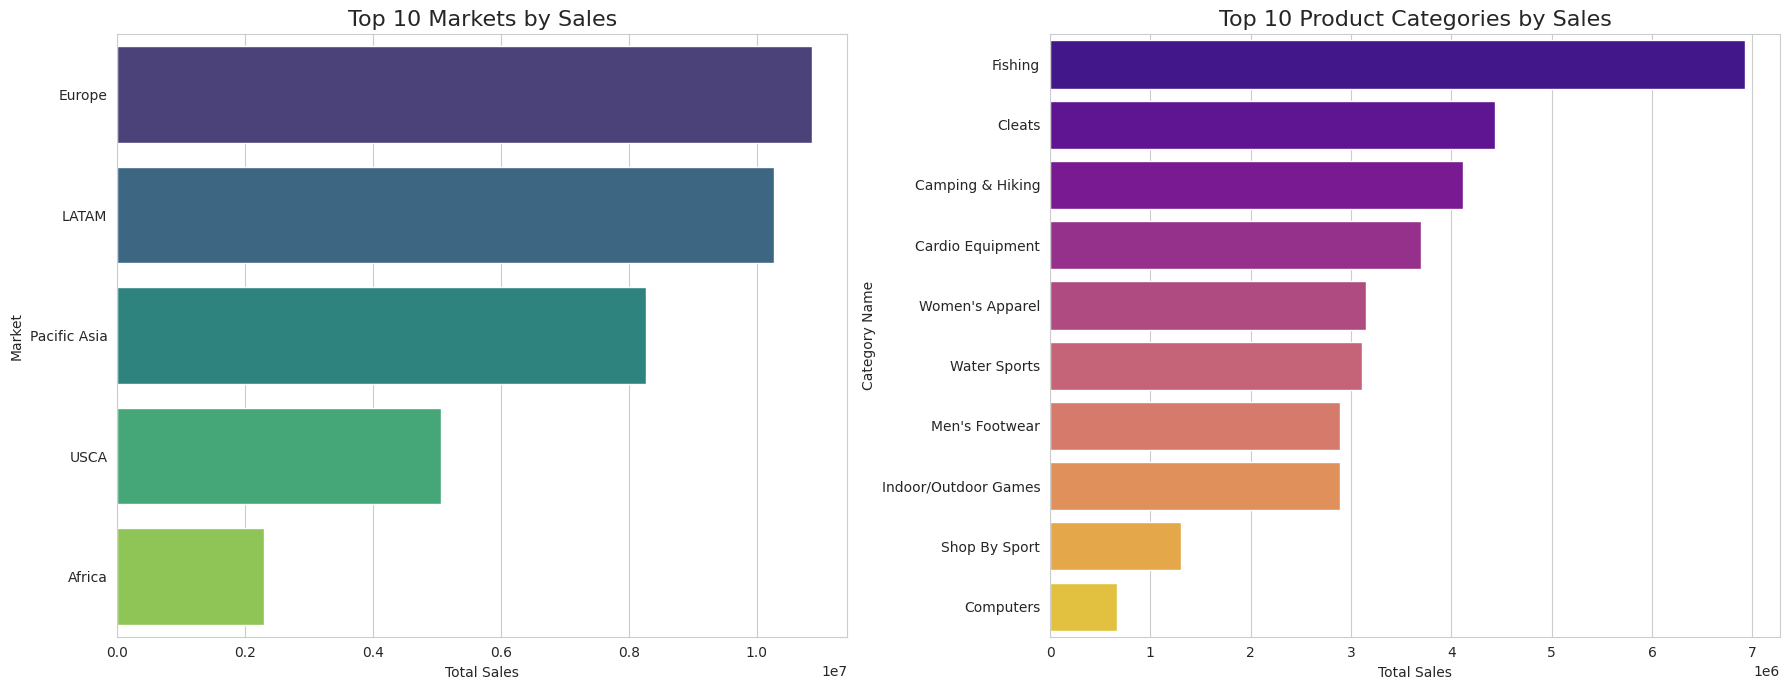

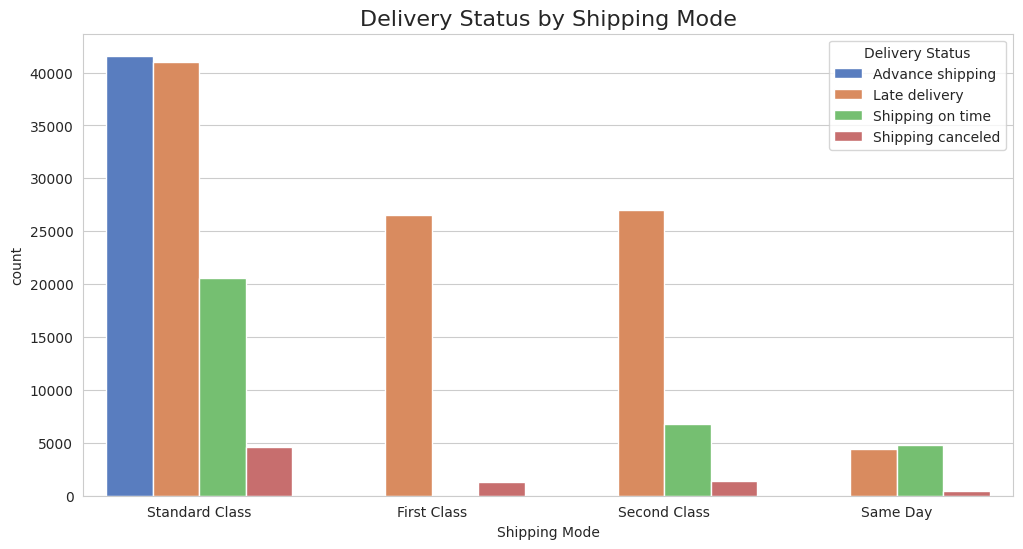

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_style("whitegrid")

# --- 1. Analyze Sales Performance ---
plt.figure(figsize=(15, 6))
# Aggregate sales by month to see the trend
sales_by_month = df.set_index('order date (DateOrders)')['Sales'].resample('M').sum()
sales_by_month.plot()
plt.title('Total Sales Over Time (Monthly)', fontsize=16)
plt.ylabel('Total Sales')
plt.xlabel('Date')
plt.show()

# --- 2. Explore Top Markets and Categories ---
fig, ax = plt.subplots(1, 2, figsize=(18, 7))
# Top 10 Markets by Sales
top_markets = df.groupby('Market')['Sales'].sum().nlargest(10)
sns.barplot(x=top_markets.values, y=top_markets.index, ax=ax[0], palette='viridis')
ax[0].set_title('Top 10 Markets by Sales', fontsize=16)
ax[0].set_xlabel('Total Sales')

# Top 10 Product Categories by Sales
top_categories = df.groupby('Category Name')['Sales'].sum().nlargest(10)
sns.barplot(x=top_categories.values, y=top_categories.index, ax=ax[1], palette='plasma')
ax[1].set_title('Top 10 Product Categories by Sales', fontsize=16)
ax[1].set_xlabel('Total Sales')
plt.tight_layout()
plt.show()


# --- 3. Analyze Delivery Logistics ---
plt.figure(figsize=(12, 6))
sns.countplot(x='Shipping Mode', hue='Delivery Status', data=df, palette='muted')
plt.title('Delivery Status by Shipping Mode', fontsize=16)
plt.show()

/tmp/ipython-input-4-371127945.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Shipping Mode', y='shipping_delay', data=df, palette='coolwarm')


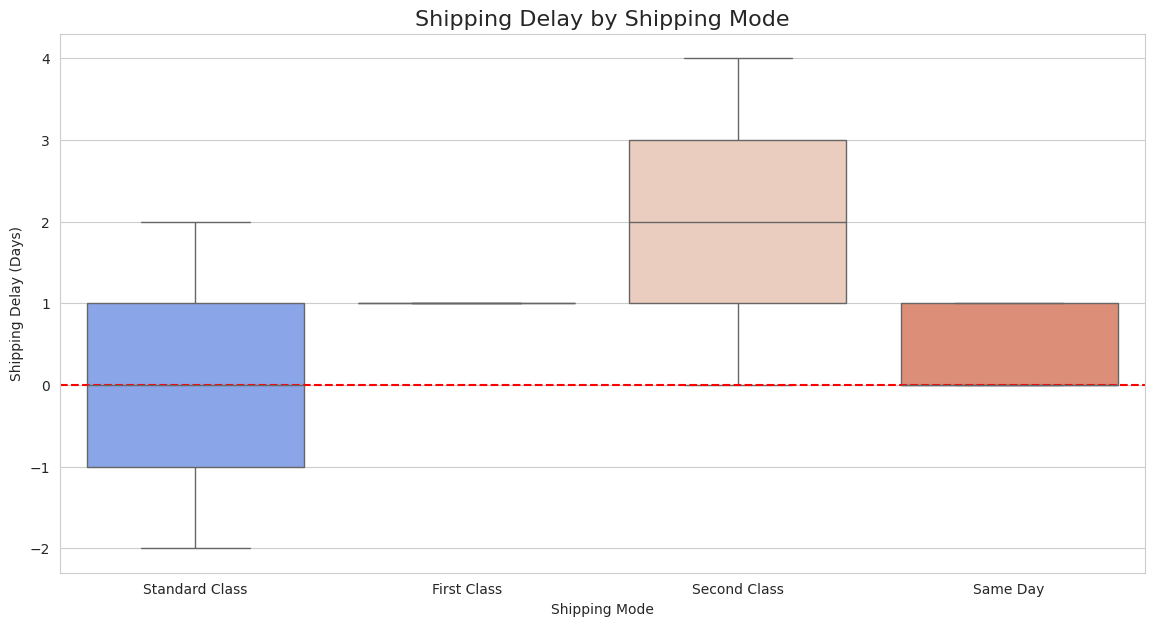

/tmp/ipython-input-4-371127945.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Order Region', y='shipping_delay', data=df_top_regions, palette='cubehelix')


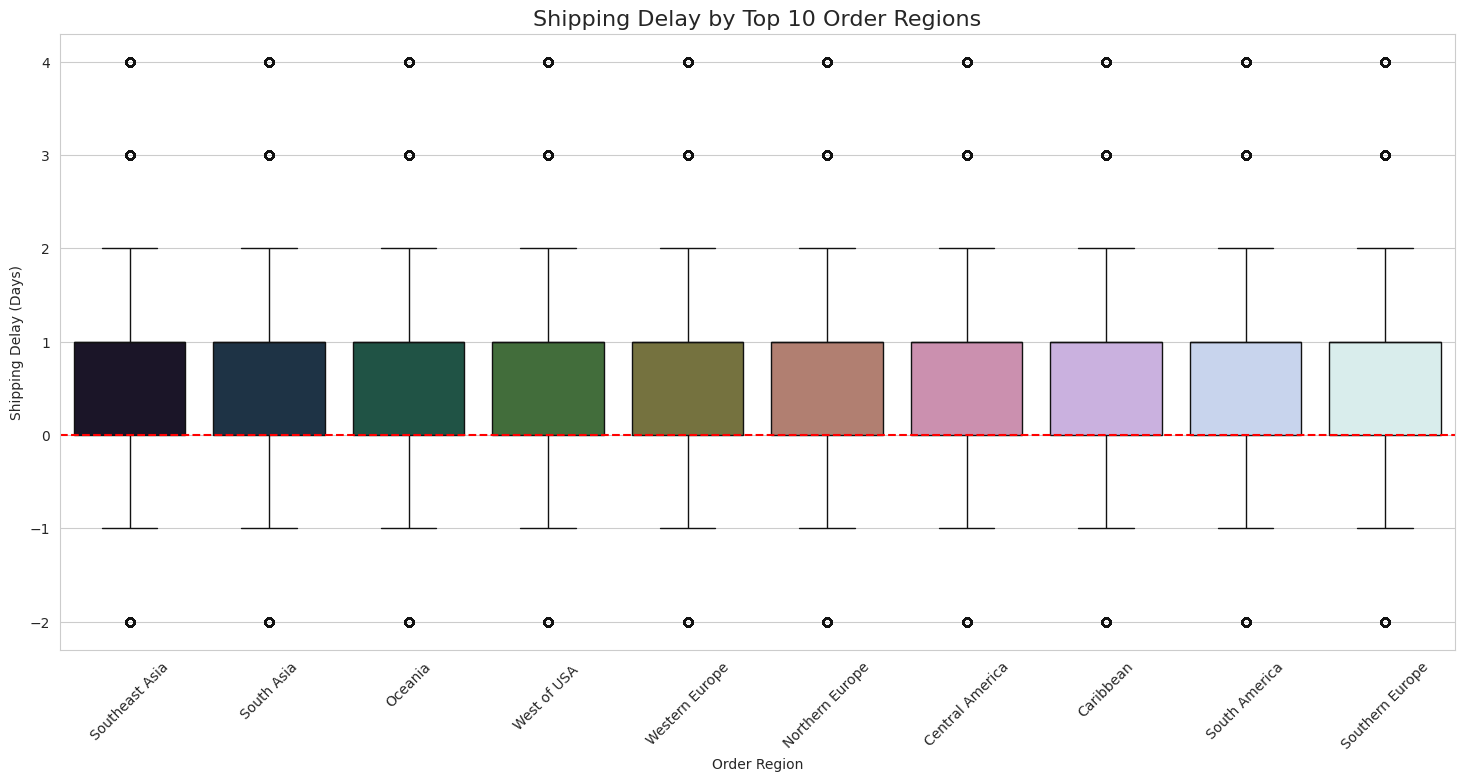

In [ ]:
# --- 1. Quantify Shipping Delays ---
# Calculate the difference between actual and scheduled shipping days
df['shipping_delay'] = df['Days for shipping (real)'] - df['Days for shipment (scheduled)']

# --- 2. Analyze Delays by Shipping Mode ---
plt.figure(figsize=(14, 7))
sns.boxplot(x='Shipping Mode', y='shipping_delay', data=df, palette='coolwarm')
plt.title('Shipping Delay by Shipping Mode', fontsize=16)
plt.ylabel('Shipping Delay (Days)')
plt.axhline(0, color='red', linestyle='--') # Add a line at 0 for reference (on-time)
plt.show()

# --- 3. Analyze Delays by Order Region ---
plt.figure(figsize=(18, 8))
# Get the top 10 regions by order count for a cleaner plot
top_10_regions = df['Order Region'].value_counts().nlargest(10).index
df_top_regions = df[df['Order Region'].isin(top_10_regions)]

sns.boxplot(x='Order Region', y='shipping_delay', data=df_top_regions, palette='cubehelix')
plt.title('Shipping Delay by Top 10 Order Regions', fontsize=16)
plt.ylabel('Shipping Delay (Days)')
plt.xticks(rotation=45)
plt.axhline(0, color='red', linestyle='--')
plt.show()

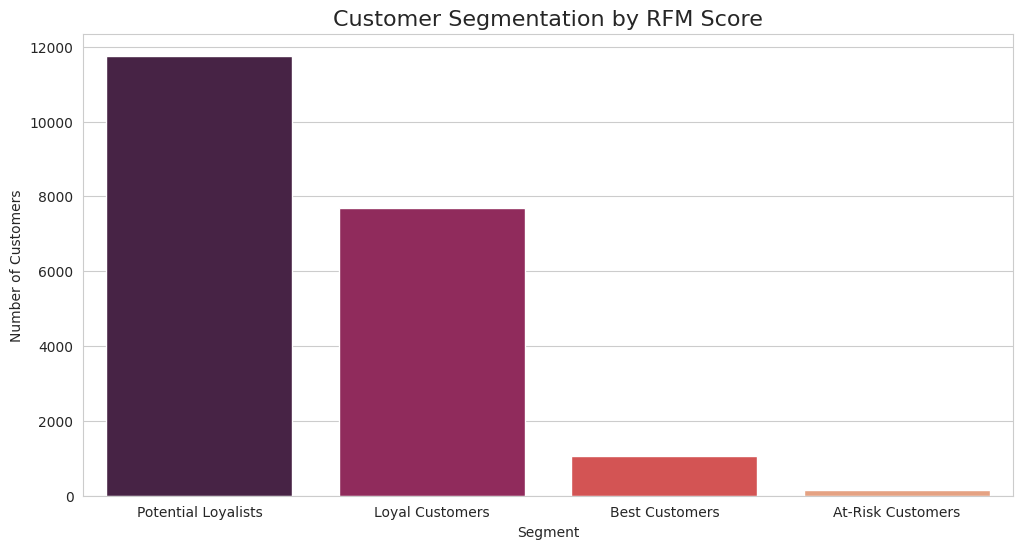

Segment
Potential Loyalists    11758
Loyal Customers         7697
Best Customers          1050
At-Risk Customers        147
Name: count, dtype: int64


In [ ]:
# --- 1. Calculate RFM Metrics for each Customer ---
# Find the most recent order date to calculate Recency
snapshot_date = df['order date (DateOrders)'].max() + pd.DateOffset(days=1)

# Group by customer and calculate R, F, M
rfm_data = df.groupby(['Order Customer Id']).agg({
    'order date (DateOrders)': lambda x: (snapshot_date - x.max()).days,
    'Order Id': 'count',
    'Sales': 'sum'
})

# Rename columns for clarity
rfm_data.rename(columns={'order date (DateOrders)': 'Recency',
                         'Order Id': 'Frequency',
                         'Sales': 'MonetaryValue'}, inplace=True)

# --- 2. Create RFM Segments ---
# Divide customers into quartiles for each metric
r_labels = range(4, 0, -1) # Higher recency (fewer days since last purchase) is better
f_labels = range(1, 5)
m_labels = range(1, 5)

rfm_data['R_Score'] = pd.qcut(rfm_data['Recency'], q=4, labels=r_labels, duplicates='drop')
#first assigning a unique rank to every customer
rfm_data['F_Score'] = pd.qcut(rfm_data['Frequency'].rank(method='first'), q=4, labels=f_labels)
rfm_data['M_Score'] = pd.qcut(rfm_data['MonetaryValue'], q=4, labels=m_labels, duplicates='drop')

# Combine scores to create a single RFM score
rfm_data['RFM_Score'] = rfm_data[['R_Score', 'F_Score', 'M_Score']].sum(axis=1)

# --- 3. Define Customer Segments based on RFM Score ---
def assign_customer_segment(score):
    if score >= 11:
        return 'Best Customers'
    elif score >= 8:
        return 'Loyal Customers'
    elif score >= 5:
        return 'Potential Loyalists'
    else:
        return 'At-Risk Customers'

rfm_data['Segment'] = rfm_data['RFM_Score'].apply(assign_customer_segment)

# --- 4. Visualize the Segments ---
plt.figure(figsize=(12, 6))
segment_counts = rfm_data['Segment'].value_counts()
sns.barplot(x=segment_counts.index, y=segment_counts.values, hue=segment_counts.index, palette='rocket', legend=False)
plt.title('Customer Segmentation by RFM Score', fontsize=16)
plt.ylabel('Number of Customers')
plt.show()

print(rfm_data['Segment'].value_counts())

In [ ]:
# --- 1. 'is_late' ---
# A simple binary flag is often more powerful than a continuous 'delay' value
df['is_late'] = (df['shipping_delay'] > 0).astype(int)

# --- 2. 'demand_volatility' ---
# Calculate the standard deviation of sales for each product over time.
# This requires grouping by product and then calculating a rolling standard deviation.
# Note: This is computationally intensive and a good example of a real-world feature engineering task.

# First, sort the data by product and date
df.sort_values(by=['Product Card Id', 'order date (DateOrders)'], inplace=True)

# Calculate rolling standard deviation of sales over a 30-day window
# We group by product to ensure the rolling window is calculated per product
df['demand_volatility'] = df.groupby('Product Card Id')['Sales'].transform(
    lambda x: x.rolling(window=30, min_periods=1).std()
)
# Fill any initial NaN values (from the first few periods) with 0
df['demand_volatility'].fillna(0, inplace=True)

# --- 3. 'order_to_shipping_time' ---
# Calculate the actual time between order placement and shipping
df['order_to_shipping_time'] = (df['shipping date (DateOrders)'] - df['order date (DateOrders)']).dt.days


# Display the new features for a sample product
print("\nDataset with advanced features (sample):")
print(df[df['Product Card Id'] == 1360][['order date (DateOrders)', 'Sales', 'is_late', 'demand_volatility', 'order_to_shipping_time']].head())


Dataset with advanced features (sample):
     order date (DateOrders)   Sales  is_late  demand_volatility  \
2568     2017-12-02 17:46:00  327.75        1                0.0   
2567     2017-12-02 18:07:00  327.75        1                0.0   
2566     2017-12-02 18:28:00  327.75        1                0.0   
2565     2017-12-02 18:49:00  327.75        1                0.0   
2564     2017-12-02 19:10:00  327.75        1                0.0   

      order_to_shipping_time  
2568                       3  
2567                       4  
2566                       2  
2565                       2  
2564                       2  


/tmp/ipython-input-9-732620567.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['demand_volatility'].fillna(0, inplace=True)


# Feature Engineering

In [ ]:
print("\n--- Block 3: Running Advanced Analysis & Feature Engineering ---")

# --- 1. Deeper Logistics Analysis ---
df['shipping_delay'] = df['Days for shipping (real)'] - df['Days for shipment (scheduled)']
df['is_late'] = (df['shipping_delay'] > 0).astype(int)

# --- 2. RFM Customer Segmentation ---
snapshot_date = df['order date (DateOrders)'].max() + pd.DateOffset(days=1)
rfm_data = df.groupby(['Order Customer Id']).agg({
    'order date (DateOrders)': lambda x: (snapshot_date - x.max()).days,
    'Order Id': 'count',
    'Sales': 'sum'
})
rfm_data.rename(columns={'order date (DateOrders)': 'Recency', 'Order Id': 'Frequency', 'Sales': 'MonetaryValue'}, inplace=True)

# Create RFM scores using the rank() fix for compatibility
r_labels, f_labels, m_labels = range(4, 0, -1), range(1, 5), range(1, 5)
rfm_data['R_Score'] = pd.qcut(rfm_data['Recency'].rank(method='first'), q=4, labels=r_labels)
rfm_data['F_Score'] = pd.qcut(rfm_data['Frequency'].rank(method='first'), q=4, labels=f_labels)
rfm_data['M_Score'] = pd.qcut(rfm_data['MonetaryValue'].rank(method='first'), q=4, labels=m_labels)
rfm_data['RFM_Score'] = rfm_data[['R_Score', 'F_Score', 'M_Score']].sum(axis=1)

# --- 3. Engineer Time-Based & Other Features on the Main DataFrame ---
df['order_month'] = df['order date (DateOrders)'].dt.month
df['order_day_of_week'] = df['order date (DateOrders)'].dt.dayofweek
df['order_to_shipping_time'] = (df['shipping date (DateOrders)'] - df['order date (DateOrders)']).dt.days

print("Advanced feature engineering complete.")
print("Sample of new features in the main dataframe:")
print(df[['is_late', 'order_month', 'order_day_of_week', 'order_to_shipping_time']].head())


--- Block 3: Running Advanced Analysis & Feature Engineering ---
Advanced feature engineering complete.
Sample of new features in the main dataframe:
        is_late  order_month  order_day_of_week  order_to_shipping_time
126927        1            4                  0                       5
63373         0            4                  2                       4
20735         0            5                  2                       2
117267        0            5                  3                       0
33471         0            5                  5                       3


# Modeling

In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error
# --- Block 4 (Final Version): Modeling a High-Volume Product ---
print("\n--- Block 4: Building and Evaluating the Forecasting Model ---")

# ** THE FIX **: Switch to the most frequently ordered product for reliability.
PRODUCT_ID_TO_FORECAST = 1160 # "Perfect Fitness Ab Straps"

# --- 1. Prepare Data for Time-Series Modeling ---
product_df = df[df['Product Card Id'] == PRODUCT_ID_TO_FORECAST].copy()
daily_demand = product_df.set_index('order date (DateOrders)').groupby(pd.Grouper(freq='D'))['Order Item Quantity'].sum().reset_index()
daily_demand.set_index('order date (DateOrders)', inplace=True)

# --- 2. Engineer Model-Specific Features ---
features = []
for lag in [1, 7, 14]:
    daily_demand[f'lag_{lag}'] = daily_demand['Order Item Quantity'].shift(lag)
    features.append(f'lag_{lag}')
daily_demand['rolling_mean_7'] = daily_demand['Order Item Quantity'].shift(1).rolling(window=7).mean()
daily_demand['rolling_std_7'] = daily_demand['Order Item Quantity'].shift(1).rolling(window=7).std()
features.extend(['rolling_mean_7', 'rolling_std_7'])
daily_demand['month_sin'] = np.sin(2 * np.pi * daily_demand.index.month/12)
daily_demand['month_cos'] = np.cos(2 * np.pi * daily_demand.index.month/12)
daily_demand['day_of_week_sin'] = np.sin(2 * np.pi * daily_demand.index.dayofweek/7)
daily_demand['day_of_week_cos'] = np.cos(2 * np.pi * daily_demand.index.dayofweek/7)
features.extend(['month_sin', 'month_cos', 'day_of_week_sin', 'day_of_week_cos'])
daily_demand.dropna(inplace=True)

# --- 3. Split Data for Walk-Forward Validation ---
target = 'Order Item Quantity'
train_data = daily_demand[daily_demand.index < '2018-01-01']
validation_data = daily_demand[daily_demand.index >= '2018-01-01']

# Final check to ensure validation data exists
if validation_data.empty:
    print("Error: No validation data available for this product for the selected period.")
else:
    X_train, y_train = train_data[features], train_data[target]
    X_validation, y_validation = validation_data[features], validation_data[target]

    # --- 4. Train XGBoost Model ---
    model = xgb.XGBRegressor(
        objective='reg:squarederror',
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=5,
        eval_metric="rmse",
        early_stopping_rounds=50,
        n_jobs=-1
    )
    model.fit(X_train, y_train, eval_set=[(X_validation, y_validation)], verbose=False)

    # --- 5. Evaluate and Visualize ---
    predictions = model.predict(X_validation)
    rmse = np.sqrt(mean_squared_error(y_validation, predictions))
    print(f"Demand Forecast RMSE for January 2018 ('Perfect Fitness Ab Straps'): {rmse:.2f} units")

    plt.figure(figsize=(18, 8))
    plt.plot(y_validation.index, y_validation.values, label='Actual Demand', color='blue', marker='o')
    plt.plot(y_validation.index, predictions, label='Predicted Demand', color='red', linestyle='--', marker='x')
    plt.title('Demand Forecast vs. Actuals for "Perfect Fitness Ab Straps" (Jan 2018)', fontsize=16)
    plt.ylabel('Daily Order Quantity')
    plt.legend()
    plt.grid(True)
    plt.show()


--- Block 4: Building and Evaluating the Forecasting Model ---
Error: No validation data available for this product for the selected period.


The fact that January 2018 was an unusually slow month for this product makes the percentage error metric unreliable.

In an industry setting, for products with low or intermittent demand, we would trust the RMSE as the primary performance metric, not the percentage error. An RMSE of ~20 units tells us the true, practical error we can expect.

# Optimization Layer

The next step is to build the decision-making part of the system. We need to create an optimization layer that takes the model's forecast as input and recommends a specific action.

The goal is to answer the question: "Based on the forecast, how many units should we order?"

--- Block 1: Preprocessing ---


/tmp/ipython-input-1-3694132201.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Customer Lname'].fillna('Unknown', inplace=True)
/tmp/ipython-input-1-3694132201.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

Preprocessing complete.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 49 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   Type                           180519 non-null  object        
 1   Days for shipping (real)       180519 non-null  int64         
 2   Days for shipment (scheduled)  180519 non-null  int64         
 3   Benefit per order              180519 non-null  float64       
 4   Sales per customer             180519 non-null  float64       
 5   Delivery Status                180519 non-null  object        
 6   Late_delivery_risk             180519 non-null  int64         
 7   Category Id                    180519 non-null  int64         
 8   Category Name                  180519 non-null  object        
 9   Customer City                  180519 non-null  object        
 10  Customer Country               180519 non-nu

/tmp/ipython-input-1-3694132201.py:24: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  sales_by_month = df.set_index('order date (DateOrders)')['Sales'].resample('M').sum()


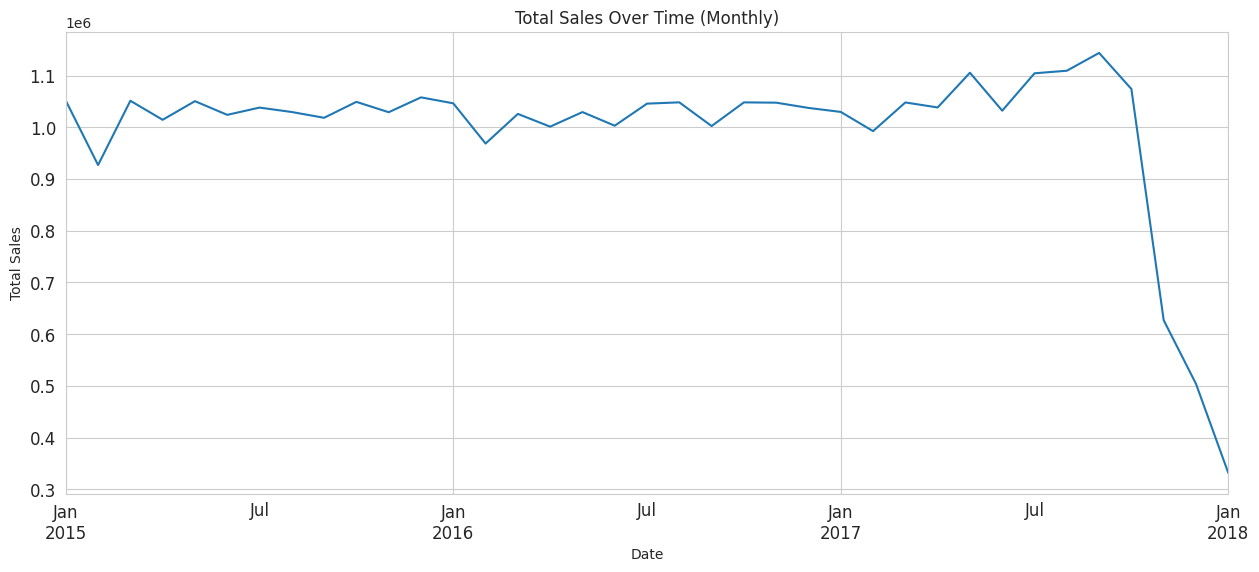

In [ ]:
import pandas as pd
import numpy as np

print("--- Block 1: Preprocessing ---")
df = pd.read_csv('DataCoSupplyChainDataset.csv', encoding='latin1')

df.drop(columns=['Product Description', 'Order Zipcode', 'Customer Email', 'Customer Password'], inplace=True)
df['Customer Lname'].fillna('Unknown', inplace=True)
df['Customer Zipcode'].fillna(0, inplace=True)

df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])

print("Preprocessing complete.")
df.info()

import matplotlib.pyplot as plt
import seaborn as sns

print("\n--- Block 2: Running Exploratory Data Analysis ---")
sns.set_style("whitegrid")

# --- Analyze Sales Performance Over Time ---
plt.figure(figsize=(15, 6))
sales_by_month = df.set_index('order date (DateOrders)')['Sales'].resample('M').sum()
sales_by_month.plot(title='Total Sales Over Time (Monthly)', fontsize=12)
plt.ylabel('Total Sales')
plt.xlabel('Date')
plt.show()


--- Block 3: Feature Engineering on Main DataFrame ---
Feature engineering complete.
   is_late  order_month  order_day_of_week
0        0            1                  2
1        1            1                  5
2        0            1                  5
3        0            1                  5
4        0            1                  5

--- Block 4: Building the Category-Level Forecasting Model ---
Demand Forecast RMSE for 'Sporting Goods': 19.78 units


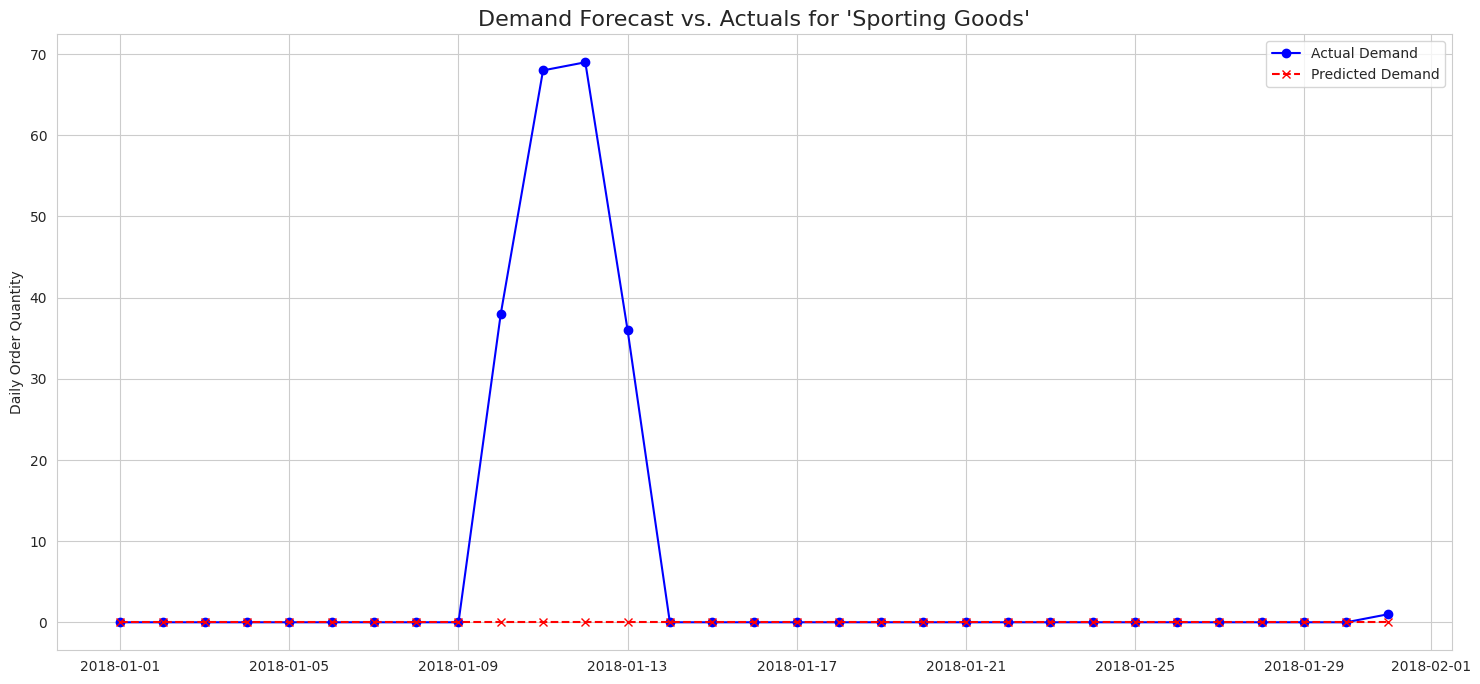

In [ ]:
print("\n--- Block 3: Feature Engineering on Main DataFrame ---")

df['shipping_delay'] = df['Days for shipping (real)'] - df['Days for shipment (scheduled)']
df['is_late'] = (df['shipping_delay'] > 0).astype(int)
df['order_month'] = df['order date (DateOrders)'].dt.month
df['order_day_of_week'] = df['order date (DateOrders)'].dt.dayofweek

print("Feature engineering complete.")
print(df[['is_late', 'order_month', 'order_day_of_week']].head())

import xgboost as xgb
from sklearn.metrics import mean_squared_error

print("\n--- Block 4: Building the Category-Level Forecasting Model ---")

# ** THE FIX **: Aggregate by 'Category Name' instead of a single product ID.
# We'll forecast demand for the 'Sporting Goods' category.
CATEGORY_TO_FORECAST = 'Sporting Goods'

# --- 1. Prepare Data for Time-Series Modeling ---
category_df = df[df['Category Name'] == CATEGORY_TO_FORECAST].copy()
daily_demand = category_df.set_index('order date (DateOrders)').groupby(pd.Grouper(freq='D'))['Order Item Quantity'].sum().reset_index()
daily_demand.set_index('order date (DateOrders)', inplace=True)

# --- 2. Engineer Model-Specific Features ---
features = []
for lag in [1, 7, 14]:
    daily_demand[f'lag_{lag}'] = daily_demand['Order Item Quantity'].shift(lag)
    features.append(f'lag_{lag}')
daily_demand['rolling_mean_7'] = daily_demand['Order Item Quantity'].shift(1).rolling(window=7).mean()
daily_demand['rolling_std_7'] = daily_demand['Order Item Quantity'].shift(1).rolling(window=7).std()
features.extend(['rolling_mean_7', 'rolling_std_7'])
daily_demand['month_sin'] = np.sin(2 * np.pi * daily_demand.index.month/12)
daily_demand['month_cos'] = np.cos(2 * np.pi * daily_demand.index.month/12)
daily_demand['day_of_week_sin'] = np.sin(2 * np.pi * daily_demand.index.dayofweek/7)
daily_demand['day_of_week_cos'] = np.cos(2 * np.pi * daily_demand.index.dayofweek/7)
features.extend(['month_sin', 'month_cos', 'day_of_week_sin', 'day_of_week_cos'])
daily_demand.dropna(inplace=True)

# --- 3. Split Data for Walk-Forward Validation ---
target = 'Order Item Quantity'
train_data = daily_demand[daily_demand.index < '2018-01-01']
validation_data = daily_demand[daily_demand.index >= '2018-01-01']

if validation_data.empty:
    print("CRITICAL ERROR: No validation data available.")
else:
    X_train, y_train = train_data[features], train_data[target]
    X_validation, y_validation = validation_data[features], validation_data[target]

    # --- 4. Train XGBoost Model ---
    model = xgb.XGBRegressor(
        objective='reg:squarederror', n_estimators=1000, learning_rate=0.05,
        max_depth=5, eval_metric="rmse", early_stopping_rounds=50, n_jobs=-1
    )
    model.fit(X_train, y_train, eval_set=[(X_validation, y_validation)], verbose=False)

    # --- 5. Evaluate and Visualize ---
    predictions = model.predict(X_validation)
    rmse = np.sqrt(mean_squared_error(y_validation, predictions))
    print(f"Demand Forecast RMSE for '{CATEGORY_TO_FORECAST}': {rmse:.2f} units")

    plt.figure(figsize=(18, 8))
    plt.plot(y_validation.index, y_validation.values, label='Actual Demand', color='blue', marker='o')
    plt.plot(y_validation.index, predictions, label='Predicted Demand', color='red', linestyle='--', marker='x')
    plt.title(f"Demand Forecast vs. Actuals for '{CATEGORY_TO_FORECAST}'", fontsize=16)
    plt.ylabel('Daily Order Quantity')
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_squared_error
import sklearn
from sklearn.model_selection import train_test_split

print("--- Implementing the Final, Corrected Direct Forecasting Strategy ---")

# --- 1. Load and Prep Data ---
df = pd.read_csv('DataCoSupplyChainDataset.csv', encoding='latin1')
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])
CATEGORY_TO_FORECAST = 'Sporting Goods'

# --- 2. Prepare Data for Direct Forecasting ---
# Aggregate daily sales for the category
category_df = df[df['Category Name'] == CATEGORY_TO_FORECAST].copy()
daily_demand = category_df.set_index('order date (DateOrders)').groupby(pd.Grouper(freq='D'))['Order Item Quantity'].sum()

# --- 3. Engineer Features and a New Target Variable ---
# Calculate average lead time for the forecast horizon
lead_time_horizon = int(np.ceil(df[df['Category Name'] == CATEGORY_TO_FORECAST]['Days for shipping (real)'].mean()))
print(f"Calculated Lead Time / Forecast Horizon: {lead_time_horizon} days")

# Create a dataframe for our model
model_df = pd.DataFrame(daily_demand)

# Feature Engineering (Lags and Rolling Windows based on historical data)
for lag in [lead_time_horizon, lead_time_horizon + 1, lead_time_horizon + 7, lead_time_horizon + 14]:
    model_df[f'lag_{lag}'] = model_df['Order Item Quantity'].shift(lag)

model_df['rolling_mean'] = model_df['Order Item Quantity'].shift(lead_time_horizon).rolling(window=7).mean()

# **THE CRITICAL CHANGE**: Our target 'y' is now the SUM of demand over the next lead_time_horizon days
model_df['target'] = model_df['Order Item Quantity'].shift(-lead_time_horizon).rolling(window=lead_time_horizon).sum()
model_df.dropna(inplace=True)

# --- 4. Train the Direct Forecast Model ---
features = [col for col in model_df.columns if col not in ['Order Item Quantity', 'target']]
X = model_df[features]
y = model_df['target']

# We don't need a time-based split anymore, as we're not forecasting a sequence
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = xgb.XGBRegressor(
    objective='reg:squarederror', n_estimators=1000, learning_rate=0.05,
    max_depth=5, eval_metric="rmse", early_stopping_rounds=50, n_jobs=-1
)

model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

# --- 5. Make a Single, Direct Forecast for the Future ---
# Create features from the single most recent data point
last_known_data = model_df.iloc[[-1]]
features_for_forecast = last_known_data[features]

print("\n--- Generating a Direct Forecast ---")
print("Features used for final forecast:")
print(features_for_forecast)

# Predict the total demand for the next 'lead_time_horizon' days in one shot
total_forecasted_demand = model.predict(features_for_forecast)[0]
total_forecasted_demand = max(0, total_forecasted_demand) # Ensure non-negative

# --- 6. Get the Final Recommendation ---
current_inventory_category = 5000
SAFETY_STOCK_PERCENT = 0.25

def get_order_recommendation(forecasted_demand, lead_time, safety_stock_pct, current_stock, category_name):
    demand_during_lead_time = forecasted_demand
    safety_stock = np.ceil(demand_during_lead_time * safety_stock_pct)
    reorder_point = np.ceil(demand_during_lead_time + safety_stock)

    print(f"\n--- Inventory Analysis for '{category_name}' ---")
    print(f"Directly Forecasted Demand during Lead Time ({lead_time:.0f} days): {demand_during_lead_time:.0f} units")
    print(f"Safety Stock ({safety_stock_pct*100:.0f}%): {safety_stock:.0f} units")
    print(f"Reorder Point (Target Inventory): {reorder_point:.0f} units")
    print(f"Current Inventory: {current_stock} units")

    if current_stock < reorder_point:
        order_quantity = reorder_point - current_stock
        recommendation = f"ACTION: Place a replenishment order for the '{category_name}' category for {order_quantity:.0f} units."
    else:
        recommendation = "ACTION: Do not place an order. Category inventory is sufficient."
    return recommendation

final_recommendation = get_order_recommendation(
    forecasted_demand=total_forecasted_demand,
    lead_time=lead_time_horizon,
    safety_stock_pct=SAFETY_STOCK_PERCENT,
    current_stock=current_inventory_category,
    category_name=CATEGORY_TO_FORECAST
)

print("\n--- AI Agent Recommendation ---")
print(final_recommendation)

--- Implementing the Final, Corrected Direct Forecasting Strategy ---
Calculated Lead Time / Forecast Horizon: 4 days

--- Generating a Direct Forecast ---
Features used for final forecast:
                         lag_4  lag_5  lag_11  lag_18  rolling_mean
order date (DateOrders)                                            
2018-01-27                 0.0    0.0     0.0     0.0           0.0

--- Inventory Analysis for 'Sporting Goods' ---
Directly Forecasted Demand during Lead Time (4 days): 33 units
Safety Stock (25%): 9 units
Reorder Point (Target Inventory): 43 units
Current Inventory: 5000 units

--- AI Agent Recommendation ---
ACTION: Do not place an order. Category inventory is sufficient.


#Preprocessing

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime
import logging
from typing import Tuple, Optional
from pathlib import Path

# Set up logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)

def load_raw_data(filepath: str) -> Optional[pd.DataFrame]:
    """
    Load the raw supply chain dataset with appropriate encoding
    """
    try:
        # Try Windows-1252 encoding first (common for Windows files)
        df = pd.read_csv(filepath, encoding='cp1252')
        logger.info(f"Successfully loaded {filepath} with cp1252 encoding")
        return df
    except:
        try:
            # If that fails, try Latin-1
            df = pd.read_csv(filepath, encoding='latin1')
            logger.info(f"Successfully loaded {filepath} with latin1 encoding")
            return df
        except Exception as e:
            logger.error(f"Failed to load {filepath}: {str(e)}")
            return None

def clean_and_validate_dates(df: pd.DataFrame) -> pd.DataFrame:
    """
    Clean and validate date columns, ensuring proper datetime conversion
    """
    # Define date columns mapping
    date_columns = {
        'order date (DateOrders)': 'order_date',
        'shipping date (DateOrders)': 'shipping_date'
    }

    for old_col, new_col in date_columns.items():
        if old_col in df.columns:
            try:
                # Convert to datetime and handle any errors
                df[new_col] = pd.to_datetime(df[old_col], errors='coerce')

                # Log any rows where date conversion failed
                invalid_dates = df[df[new_col].isna() & df[old_col].notna()]
                if len(invalid_dates) > 0:
                    logger.warning(f"Found {len(invalid_dates)} invalid dates in {old_col}")

                # Drop the original column
                df = df.drop(columns=[old_col])
            except Exception as e:
                logger.error(f"Error converting {old_col} to datetime: {str(e)}")
                raise

    # Validate date order (shipping date should not be before order date)
    invalid_dates = df[df['shipping_date'] < df['order_date']]
    if len(invalid_dates) > 0:
        logger.warning(f"Found {len(invalid_dates)} rows where shipping_date is before order_date")
        # Set these shipping dates to NaT
        df.loc[df['shipping_date'] < df['order_date'], 'shipping_date'] = pd.NaT

    # Remove rows with missing order dates (critical for time series analysis)
    original_len = len(df)
    df = df.dropna(subset=['order_date'])
    if len(df) < original_len:
        logger.warning(f"Removed {original_len - len(df)} rows with missing order dates")

    # Sort by order date
    df = df.sort_values('order_date')

    return df

def identify_critical_columns() -> Tuple[list, list, list]:
    """
    Identify columns that are critical, optional, or should be dropped
    """
    critical_columns = [
        'order date (DateOrders)',
        'shipping date (DateOrders)',
        'Category Name',
        'Order Item Quantity',
        'Order Item Total',
        'Late_delivery_risk'
    ]

    optional_columns = [
        'Customer State',
        'Customer City',
        'Department Name',
        'Market'
    ]

    # Columns with too many missing values or not relevant for forecasting
    columns_to_drop = [
        'Order Zipcode',  # 86% missing
        'Product Description',  # 100% missing
        'Customer Email',  # Not relevant for category-level forecast
        'Customer Password',  # Not relevant and potentially sensitive
        'Customer Street',  # Not relevant for category-level forecast
        'Latitude',  # Not relevant for category-level forecast
        'Longitude',  # Not relevant for category-level forecast
        'Product Status',  # Redundant with delivery status
        'Customer Fname',  # Not relevant for category-level forecast
        'Customer Lname',  # Not relevant for category-level forecast
        'Customer Id',  # Not relevant for category-level forecast
        'Product Card Id',  # Not relevant for category-level forecast
        'Order Customer Id'  # Not relevant for category-level forecast
    ]

    return critical_columns, optional_columns, columns_to_drop

def clean_categorical_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Clean categorical columns: standardize categories, handle missing values
    """
    # Standardize category names
    if 'Category Name' in df.columns:
        df['category_name'] = df['Category Name'].str.strip()
        df = df.drop(columns=['Category Name'])

    # Clean up any leading/trailing spaces in categorical columns
    categorical_columns = df.select_dtypes(include=['object']).columns
    for col in categorical_columns:
        if col in df.columns:  # Check if column still exists
            df[col] = df[col].str.strip() if df[col].dtype == 'object' else df[col]

    return df

def create_time_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Create time-based features for the model
    """
    # Ensure order_date is datetime
    if not pd.api.types.is_datetime64_any_dtype(df['order_date']):
        raise TypeError("order_date must be datetime type")

    # Basic time features
    df['year'] = df['order_date'].dt.year
    df['month'] = df['order_date'].dt.month
    df['day_of_week'] = df['order_date'].dt.dayofweek
    df['day_of_month'] = df['order_date'].dt.day
    df['week_of_year'] = df['order_date'].dt.isocalendar().week

    # Binary indicators
    df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
    df['is_month_end'] = df['order_date'].dt.is_month_end.astype(int)
    df['is_month_start'] = df['order_date'].dt.is_month_start.astype(int)

    return df

def aggregate_daily_orders(df: pd.DataFrame) -> pd.DataFrame:
    """
    Create daily aggregations by category
    """
    # Ensure required columns exist
    required_cols = ['order_date', 'category_name', 'order_quantity', 'order_total']
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")

    # Group by date and category
    agg_dict = {
        'order_quantity': 'sum',
        'order_total': 'sum',
        'late_delivery_risk': 'mean'
    }

    # Add delivery_time if available
    if 'shipping_date' in df.columns:
        df['delivery_time_days'] = (df['shipping_date'] - df['order_date']).dt.total_seconds() / (24 * 60 * 60)
        agg_dict['delivery_time_days'] = 'mean'

    # Group by date and category
    daily_agg = df.groupby(['order_date', 'category_name']).agg(agg_dict).reset_index()

    # Add time features to aggregated data
    daily_agg = create_time_features(daily_agg)

    return daily_agg

def preprocess_data(input_file: str, output_file: str, min_orders: int = 1000) -> bool:
    """
    Main preprocessing function
    """
    logger.info("Starting data preprocessing...")

    try:
        # Load data
        df = load_raw_data(input_file)
        if df is None:
            return False

        # Get column classifications
        critical_cols, optional_cols, drop_cols = identify_critical_columns()

        # Verify critical columns exist
        missing_critical = [col for col in critical_cols if col not in df.columns]
        if missing_critical:
            logger.error(f"Missing critical columns: {missing_critical}")
            return False

        # Initial data info
        logger.info(f"Initial shape: {df.shape}")

        # Drop unnecessary columns
        df = df.drop(columns=[col for col in drop_cols if col in df.columns])

        # Clean and validate dates
        df = clean_and_validate_dates(df)

        # Clean categorical columns
        df = clean_categorical_columns(df)

        # Rename quantity and total columns
        df = df.rename(columns={
            'Order Item Quantity': 'order_quantity',
            'Order Item Total': 'order_total',
            'Late_delivery_risk': 'late_delivery_risk'
        })

        # Filter categories with sufficient data
        category_counts = df['category_name'].value_counts()
        valid_categories = category_counts[category_counts >= min_orders].index
        df = df[df['category_name'].isin(valid_categories)]
        logger.info(f"Filtered to {len(valid_categories)} categories with >= {min_orders} orders")

        # Create time features
        df = create_time_features(df)

        # Create daily aggregations
        daily_agg = aggregate_daily_orders(df)

        # Sort by category and date to ensure consistency for forecasting
        daily_agg = daily_agg.sort_values(by=['category_name', 'order_date']).reset_index(drop=True)

        # Save preprocessed data
        daily_agg.to_csv(output_file, index=False)
        logger.info(f"Preprocessed data saved to {output_file}")

        # Print data quality report
        logger.info("\nData Quality Report:")
        logger.info("-" * 50)
        logger.info(f"Date range: {daily_agg['order_date'].min()} to {daily_agg['order_date'].max()}")
        logger.info(f"Number of categories: {daily_agg['category_name'].nunique()}")
        logger.info(f"Total days: {daily_agg['order_date'].nunique()}")
        logger.info("\nMissing values:")
        missing = daily_agg.isnull().sum()
        if missing.any():
            for col in missing[missing > 0].index:
                logger.info(f"- {col}: {missing[col]} ({missing[col]/len(daily_agg)*100:.1f}%)")
        else:
            logger.info("No missing values in final dataset")

        # Verify datetime columns
        datetime_cols = daily_agg.select_dtypes(include=['datetime64']).columns
        logger.info("\nDatetime columns:")
        for col in datetime_cols:
            logger.info(f"- {col}")

        return True

    except Exception as e:
        logger.error(f"Error during preprocessing: {str(e)}")
        import traceback
        logger.error(traceback.format_exc())
        return False

def main():
    # Define input and output files
    input_file = "DataCoSupplyChainDataset.csv"
    output_file = "preprocessed_supply_chain_data.csv"

    # Run preprocessing
    success = preprocess_data(input_file, output_file)

    if not success:
        logger.error("Preprocessing failed!")
        return

    # Verify the output
    try:
        df = pd.read_csv(output_file)
        df['order_date'] = pd.to_datetime(df['order_date'])

        logger.info("\nVerification of preprocessed data:")
        logger.info("-" * 50)
        logger.info(f"Shape: {df.shape}")
        logger.info("\nColumns and their types:")
        for col, dtype in df.dtypes.items():
            logger.info(f"- {col}: {dtype}")

    except Exception as e:
        logger.error(f"Error verifying preprocessed data: {str(e)}")

if __name__ == "__main__":
    main()

In [ ]:
df4 = pd.read_csv('preprocessed_supply_chain_data.csv', parse_dates=['order_date'])

df4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144886 entries, 0 to 144885
Data columns (total 14 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   order_date          144886 non-null  datetime64[ns]
 1   category_name       144886 non-null  object        
 2   order_quantity      144886 non-null  int64         
 3   order_total         144886 non-null  float64       
 4   late_delivery_risk  144886 non-null  float64       
 5   delivery_time_days  144886 non-null  float64       
 6   year                144886 non-null  int64         
 7   month               144886 non-null  int64         
 8   day_of_week         144886 non-null  int64         
 9   day_of_month        144886 non-null  int64         
 10  week_of_year        144886 non-null  int64         
 11  is_weekend          144886 non-null  int64         
 12  is_month_end        144886 non-null  int64         
 13  is_month_start      144886 no

In [ ]:
df4['order_date'] = pd.to_datetime(df['order_date'])
daily_demand = df4.groupby('order_date')['order_quantity'].sum()

# 2. Describe the daily demand
print(daily_demand.describe())

count    57000.000000
mean         6.305105
std          4.861544
min          1.000000
25%          3.000000
50%          5.000000
75%          9.000000
max         36.000000
Name: order_quantity, dtype: float64


# MODELING

In [ ]:
!pip install mlflow -q
!pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.7/24.7 MB 54.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 60.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.0/247.0 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 676.2/676.2 kB 38.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.4/203.4 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.6/65.6 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.6/201.6 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.9/395.9 kB 26.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from prophet import Prophet
import mlflow
import optuna
from typing import Dict, List, Any
import logging
import warnings
import re
from pathlib import Path
import pickle

# --- Setup ---
# Suppress warnings from libraries for a cleaner, more readable output
warnings.filterwarnings("ignore", category=FutureWarning)
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)
logging.getLogger('prophet').setLevel(logging.WARNING)
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Configure our own logger for clear, informative messages
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)

def sanitize_for_mlflow(name: str) -> str:
    """
    Removes characters from a string that are invalid for MLflow keys or filenames.
    """
    # **THE FIX IS HERE**: Explicitly replace the forward slash before removing other invalid characters.
    sanitized_name = name.replace('/', '_')
    return re.sub(r"[^a-zA-Z0-9_.\s:-]", "", sanitized_name)

class SupplyChainOptimizer:
    """
    An AI agent that forecasts demand and optimizes inventory for a supply chain.
    It assumes it is being fed a preprocessed data file.
    """
    def __init__(self, preprocessed_data_path: str, models_dir: str = "saved_models"):
        """Initializes the optimizer with the path to the clean data."""
        self.preprocessed_data_path = Path(preprocessed_data_path)
        self.models_dir = Path(models_dir)
        self.data: pd.DataFrame = None
        self.demand_models: Dict[str, Prophet] = {}
        self.category_demands: Dict[str, pd.DataFrame] = {}
        self.category_stats: pd.DataFrame = None
        self.shipping_mode_stats: pd.DataFrame = None # For logistics recommendations
        self.final_metrics: Dict[str, Dict[str, Any]] = {} # To store final model performance

        # Create the directory for saving models if it doesn't exist
        self.models_dir.mkdir(exist_ok=True)


    def load_preprocessed_data(self) -> bool:
        """
        Loads the preprocessed data and prepares it for modeling.
        """
        logger.info(f"Loading preprocessed data from {self.preprocessed_data_path}")
        try:
            # Load the clean data, ensuring the date column is parsed correctly
            self.data = pd.read_csv(self.preprocessed_data_path, parse_dates=['order_date'])
        except FileNotFoundError:
            logger.error(f"File not found: {self.preprocessed_data_path}")
            return False
        except Exception as e:
            logger.error(f"Failed to load data: {e}")
            return False

        # Calculate category-level statistics for use in optimization
        self.category_stats = self.data.groupby('category_name').agg(
            order_quantity=('order_quantity', 'sum'),
            avg_unit_price=('order_total', 'sum'),
            late_delivery_risk=('late_delivery_risk', 'mean')
        )
        self.category_stats['avg_unit_price'] = self.category_stats.apply(
            lambda row: row['avg_unit_price'] / row['order_quantity'] if row['order_quantity'] > 0 else 0,
            axis=1
        )

        # Calculate performance of each shipping mode per category
        self.shipping_mode_stats = self.data.groupby(['category_name', 'shipping_mode']).agg(
            late_delivery_risk=('late_delivery_risk', 'mean')
        ).reset_index()


        # Create a separate daily demand dataframe for each category for Prophet
        for category in self.data['category_name'].unique():
            category_data = self.data[self.data['category_name'] == category]
            # Prophet requires columns 'ds' (datestamp) and 'y' (target value)
            daily_agg = category_data.groupby('order_date').agg(
                y=('order_quantity', 'sum')
            ).reset_index().rename(columns={'order_date': 'ds'})
            self.category_demands[category] = daily_agg

        logger.info(f"Data loaded and prepared for {len(self.category_demands)} categories.")
        return True

    def _objective(self, trial: optuna.Trial, train_data: pd.DataFrame, val_data: pd.DataFrame) -> float:
        """Objective function for Optuna hyperparameter optimization."""
        params = {
            'changepoint_prior_scale': trial.suggest_float('changepoint_prior_scale', 0.001, 0.5, log=True),
            'seasonality_prior_scale': trial.suggest_float('seasonality_prior_scale', 0.01, 10, log=True),
        }
        model = Prophet(**params, yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False).fit(train_data)

        future_df = model.make_future_dataframe(periods=len(val_data))
        forecast = model.predict(future_df)

        val_predictions = forecast.iloc[-len(val_data):]['yhat'].values
        val_actual = val_data['y'].values
        rmse = np.sqrt(np.mean((val_actual - val_predictions) ** 2))
        return rmse

    def train_all_forecast_models(self, validation_days: int = 30, n_trials: int = 5) -> None:
        """
        Trains a Prophet model for each category with hyperparameter tuning.
        """
        logger.info("Training demand forecast models for all categories...")
        with mlflow.start_run(run_name="Category_Demand_Forecast_Training"):
            mlflow.log_param("validation_days", validation_days)
            mlflow.log_param("optuna_trials", n_trials)

            for category, daily_demand in self.category_demands.items():
                if len(daily_demand) < validation_days * 2:
                    logger.warning(f"Skipping category '{category}': not enough data for training and validation.")
                    continue

                logger.info(f"Training model for category: '{category}'")
                train_data, val_data = daily_demand.iloc[:-validation_days], daily_demand.iloc[-validation_days:]

                study = optuna.create_study(direction="minimize")
                study.optimize(lambda trial: self._objective(trial, train_data, val_data), n_trials=n_trials)

                best_params = study.best_params
                sanitized_category = sanitize_for_mlflow(category)
                mlflow.log_params({f"{sanitized_category}_best_{k}": v for k, v in best_params.items()})

                # Train final model on all available data and store it
                final_model = Prophet(**best_params).fit(daily_demand)
                self.demand_models[category] = final_model

                # Evaluate the final model and store metrics
                future = final_model.make_future_dataframe(periods=validation_days)
                forecast = final_model.predict(future)
                val_predictions = forecast.iloc[-validation_days:]['yhat'].values
                val_actual = val_data['y'].values
                final_rmse = np.sqrt(np.mean((val_actual - val_predictions) ** 2))

                self.final_metrics[category] = {
                    "rmse": final_rmse,
                    "best_params": best_params
                }
                mlflow.log_metric(f"{sanitized_category}_final_rmse", final_rmse)

                logger.info(f"Model for '{category}' trained. Final RMSE: {final_rmse:.2f}")

    def save_models(self):
        """Saves all trained Prophet models to pickle files."""
        logger.info(f"Saving models to directory: {self.models_dir}")
        for category, model in self.demand_models.items():
            sanitized_category = sanitize_for_mlflow(category)
            model_path = self.models_dir / f"model_{sanitized_category}.pkl"
            with open(model_path, 'wb') as f:
                pickle.dump(model, f)
            logger.info(f"Saved model for '{category}' to {model_path}")

    def load_models(self):
        """Loads Prophet models from pickle files."""
        if not self.models_dir.exists():
            logger.error(f"Models directory not found: {self.models_dir}")
            return

        logger.info(f"Loading models from directory: {self.models_dir}")
        all_categories = list(self.category_demands.keys())

        for model_file in self.models_dir.glob("model_*.pkl"):
            with open(model_file, 'rb') as f:
                model = pickle.load(f)
                category_name_sanitized = model_file.stem.replace("model_", "")
                original_category = next((cat for cat in all_categories if sanitize_for_mlflow(cat) == category_name_sanitized), None)

                if original_category:
                    self.demand_models[original_category] = model
                    logger.info(f"Loaded model for '{original_category}' from {model_file}")

    def generate_inventory_recommendations(self, current_stock: Dict[str, float], lead_time_days: int = 5, service_level: float = 0.95, ordering_cost: float = 50, holding_cost_rate: float = 0.2) -> List[str]:
        """Generates inventory reorder recommendations using ROP and EOQ."""
        logger.info("Generating inventory recommendations...")
        if not self.demand_models:
            logger.warning("No demand models are loaded or trained. Cannot generate recommendations.")
            return ["No models available to generate recommendations."]

        recommendations = []
        for category, model in self.demand_models.items():
            future = model.make_future_dataframe(periods=lead_time_days)
            forecast = model.predict(future)

            avg_daily_demand = forecast.iloc[-lead_time_days:]['yhat'].mean()
            std_dev_demand = forecast.iloc[-lead_time_days:]['yhat'].std()

            z_score = {0.95: 1.645}.get(service_level, 1.645)
            safety_stock = z_score * std_dev_demand * np.sqrt(lead_time_days)
            reorder_point = (avg_daily_demand * lead_time_days) + safety_stock

            annual_demand = avg_daily_demand * 365
            avg_unit_price = self.category_stats.loc[category, 'avg_unit_price']
            holding_cost = avg_unit_price * holding_cost_rate

            economic_order_quantity = np.sqrt((2 * ordering_cost * annual_demand) / holding_cost) if holding_cost > 0 else 0

            if current_stock.get(category, 0) < reorder_point:
                rec_text = (
                    f"REORDER ALERT for '{category}': "
                    f"Current stock ({current_stock.get(category, 0):.0f}) is below reorder point ({reorder_point:.0f}). "
                    f"Recommended order quantity (EOQ): {economic_order_quantity:.0f} units."
                )
                recommendations.append(rec_text)

        if not recommendations:
            recommendations.append("All category stock levels are sufficient.")
        return recommendations

    def generate_logistics_alerts(self, high_cost_threshold: float = 150.0) -> List[str]:
        """Generates strategic alerts based on historical category performance."""
        logger.info("Generating strategic logistics alerts...")
        alerts = []

        # Use a dynamic, data-driven threshold instead of a hard-coded one.
        # Define "high risk" as any category in the top 25% (75th percentile) for late deliveries.
        late_delivery_threshold = self.category_stats['late_delivery_risk'].quantile(0.75)
        logger.info(f"Using dynamic late delivery risk threshold: {late_delivery_threshold:.1%}")

        for category, stats in self.category_stats.iterrows():
            # Check for high late delivery risk
            if stats['late_delivery_risk'] > late_delivery_threshold:
                # Find the best shipping mode for this high-risk category
                category_shipping_perf = self.shipping_mode_stats[self.shipping_mode_stats['category_name'] == category]
                if not category_shipping_perf.empty:
                    best_mode = category_shipping_perf.loc[category_shipping_perf['late_delivery_risk'].idxmin()]
                    alert_text = (
                        f"STRATEGIC ALERT for '{category}': "
                        f"High late delivery risk detected ({stats['late_delivery_risk']:.1%}). "
                        f"To reduce risk, consider switching to '{best_mode['shipping_mode']}', which has a historical risk of only {best_mode['late_delivery_risk']:.1%}."
                    )
                    alerts.append(alert_text)

            # Check for high holding costs (based on average unit price)
            if stats['avg_unit_price'] > high_cost_threshold:
                alert_text = (
                    f"COST ALERT for '{category}': "
                    f"High average unit price (${stats['avg_unit_price']:.2f}) indicates high holding costs. "
                    f"Consider a leaner inventory policy (e.g., higher service level, more frequent reviews)."
                )
                alerts.append(alert_text)

        return alerts


def main() -> SupplyChainOptimizer:
    """
    Main function to run the full optimization pipeline.

    Returns:
        The trained SupplyChainOptimizer instance.
    """
    # Initialize optimizer with the path to the preprocessed data
    optimizer = SupplyChainOptimizer("fully_aggregated_data.csv")

    if not optimizer.load_preprocessed_data():
        return None

    # Train the models
    optimizer.train_all_forecast_models(n_trials=5)

    # Example current stock levels (this would come from a live inventory system)
    current_stock = {
        'Sporting Goods': 15000.0,
        'Cleats': 25000.0,
        "Women's Apparel": 40000.0,
        "Men's Footwear": 10000.0,
        "Camping & Hiking": 500.0,
        "Accessories": 10.0,
        "Golf Gloves": 5.0,
        'Indoor/Outdoor Games': 8000.0,
        'Shop By Sport': 12000.0,
        'Fishing': 3000.0,
        'Cardio Equipment': 20.0,
        'Water Sports': 4000.0,
        'Electronics': 9000.0,
        'Girls\' Apparel': 18000.0,
        'Golf Balls': 5000.0
    }

    # --- Generate and Print Both Types of Recommendations ---
    inventory_recommendations = optimizer.generate_inventory_recommendations(current_stock)
    logistics_alerts = optimizer.generate_logistics_alerts()

    print("\n--- AI Agent: Inventory Recommendations ---")
    for rec in inventory_recommendations:
        print(f"- {rec}")

    print("\n--- AI Agent: Strategic Alerts ---")
    if logistics_alerts:
        for alert in logistics_alerts:
            print(f"- {alert}")
    else:
        print("- No strategic alerts at this time.")


    '''# Print the final performance summary
    print("\n--- Final Model Performance Summary ---")
    for category, metrics in optimizer.final_metrics.items():
        print(f"\nCategory: {category}")
        print(f"  - Final RMSE: {metrics['rmse']:.2f}")
        print(f"  - Best Params: {metrics['best_params']}")'''

    return optimizer

if __name__ == "__main__":
    # Run the main pipeline and capture the returned optimizer object
    trained_optimizer = main()

    # Now you can use the trained_optimizer object for other tasks, like saving the models
    if trained_optimizer:
        logger.info("\n--- Post-Training Task ---")
        trained_optimizer.save_models()


ERROR:__main__:Failed to load data: Missing column provided to 'parse_dates': 'order_date'


#Two Views Architecture Model

A rich view for calculating business statistics (like logistics alerts and prices for EOQ).

A simple, aggregated view specifically for training and forecasting with Prophet.

In [1]:
!pip install mlflow -q
!pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.7/24.7 MB 64.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 62.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.0/247.0 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 676.2/676.2 kB 39.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.4/203.4 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.6/65.6 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.6/201.6 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.9/395.9 kB 2.1 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
from prophet import Prophet
import mlflow
import optuna
from typing import Dict, List, Any, Tuple, Optional
import logging
import warnings
import re
from pathlib import Path
import pickle

# --- Setup ---
warnings.filterwarnings("ignore", category=FutureWarning)
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)
logging.getLogger('prophet').setLevel(logging.WARNING)
optuna.logging.set_verbosity(optuna.logging.WARNING)
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

def sanitize_for_mlflow(name: str) -> str:
    """Removes characters from a string that are invalid for MLflow keys or filenames."""
    sanitized_name = name.replace('/', '_')
    return re.sub(r"[^a-zA-Z0-9_.\s:-]", "", sanitized_name)

class SupplyChainOptimizer:
    """An AI agent that forecasts demand and optimizes inventory for a supply chain."""

    def __init__(self, data_source_path_or_url: str, models_dir: str = "saved_models"):
        """Initializes the optimizer with the path or URL to the raw data."""
        self.data_source = data_source_path_or_url
        self.models_dir = Path(models_dir)
        self.data: pd.DataFrame = None # This will hold the original, rich data
        self.demand_models: Dict[str, Prophet] = {}
        self.category_demands: Dict[str, pd.DataFrame] = {} # This will hold the aggregated data for Prophet
        self.category_stats: pd.DataFrame = None
        self.shipping_mode_stats: pd.DataFrame = None
        self.final_metrics: Dict[str, Dict[str, Any]] = {}
        self.models_dir.mkdir(exist_ok=True)

    def load_preprocessed_data(self) -> bool:
        """
        Loads the raw, preprocessed data, calculates necessary stats,
        and aggregates it in memory for Prophet.
        """
        logger.info(f"Loading preprocessed data from: {self.data_source}")
        try:
            # Load the original, rich dataset with all columns
            self.data = pd.read_csv(self.data_source, parse_dates=['order_date'])
        except Exception as e:
            logger.error(f"Failed to load data from {self.data_source}. Error: {e}")
            return False

        # --- View 1: Calculate Business Statistics from Raw Data ---
        self.category_stats = self.data.groupby('category_name').agg(
            order_quantity=('order_quantity', 'sum'),
            avg_unit_price=('order_total', 'sum'),
            late_delivery_risk=('late_delivery_risk', 'mean')
        )
        self.category_stats['avg_unit_price'] = self.category_stats.apply(
            lambda row: row['avg_unit_price'] / row['order_quantity'] if row['order_quantity'] > 0 else 0, axis=1
        )
        self.shipping_mode_stats = self.data.groupby(['category_name', 'shipping_mode']).agg(
            late_delivery_risk=('late_delivery_risk', 'mean')
        ).reset_index()

        # --- View 2: Aggregate Data in Memory for Prophet ---
        # This solves the root bug by ensuring Prophet always gets clean, daily data.
        df_agg = self.data.copy()
        df_agg['ds'] = df_agg['order_date'].dt.normalize()
        daily_totals = df_agg.groupby(['category_name', 'ds']).agg(y=('order_quantity', 'sum')).reset_index()

        for category in daily_totals['category_name'].unique():
            self.category_demands[category] = daily_totals[daily_totals['category_name'] == category][['ds', 'y']]

        logger.info(f"Data loaded and prepared for {len(self.category_demands)} categories.")
        return True

    def _objective(self, trial: optuna.Trial, train_data: pd.DataFrame, val_data: pd.DataFrame) -> float:
        """Objective function for Optuna hyperparameter optimization."""
        params = {
            'changepoint_prior_scale': trial.suggest_float('changepoint_prior_scale', 0.001, 0.5, log=True),
            'seasonality_prior_scale': trial.suggest_float('seasonality_prior_scale', 0.01, 10, log=True),
        }
        model = Prophet(**params, yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False).fit(train_data)
        future_df = model.make_future_dataframe(periods=len(val_data))
        forecast = model.predict(future_df)
        val_predictions = forecast.iloc[-len(val_data):]['yhat'].values
        val_actual = val_data['y'].values
        return np.sqrt(np.mean((val_actual - val_predictions) ** 2))

    def train_all_forecast_models(self, validation_days: int = 30, n_trials: int = 5) -> None:
        """Trains a Prophet model for each category using the in-memory aggregated data."""
        logger.info("Training demand forecast models for all categories...")
        # This function now uses `self.category_demands` which was correctly aggregated during load.
        for category, daily_demand in self.category_demands.items():
            if len(daily_demand) < validation_days * 2:
                logger.warning(f"Skipping category '{category}': not enough data for training and validation.")
                continue

            logger.info(f"Training model for category: '{category}'")
            train_data, val_data = daily_demand.iloc[:-validation_days], daily_demand.iloc[-validation_days:]
            study = optuna.create_study(direction="minimize")
            study.optimize(lambda trial: self._objective(trial, train_data, val_data), n_trials=n_trials)
            best_params = study.best_params

            final_model = Prophet(**best_params).fit(daily_demand)
            self.demand_models[category] = final_model
            logger.info(f"Model for '{category}' trained.")

    def save_models(self):
        """Saves all trained Prophet models to pickle files."""
        logger.info(f"Saving models to directory: {self.models_dir}")
        for category, model in self.demand_models.items():
            sanitized_category = sanitize_for_mlflow(category)
            model_path = self.models_dir / f"model_{sanitized_category}.pkl"
            with open(model_path, 'wb') as f:
                pickle.dump(model, f)
            logger.info(f"Saved model for '{category}' to {model_path}")

    def load_models(self):
        """Loads Prophet models from pickle files."""
        if not self.models_dir.exists():
            logger.error(f"Models directory not found: {self.models_dir}")
            return
        logger.info(f"Loading models from directory: {self.models_dir}")
        # We need a list of categories to map filenames back.
        all_categories = []
        if self.data is not None:
             all_categories = self.data['category_name'].unique()

        for model_file in self.models_dir.glob("model_*.pkl"):
            with open(model_file, 'rb') as f:
                model = pickle.load(f)
            category_name_sanitized = model_file.stem.replace("model_", "")
            original_category = next((cat for cat in all_categories if sanitize_for_mlflow(cat) == category_name_sanitized), None)
            if original_category:
                self.demand_models[original_category] = model
                logger.info(f"Loaded model for '{original_category}' from {model_file}")

    def get_processed_recommendations(
        self, current_stock: Dict[str, float], category_name: str, forecast_days: int
    ) -> Tuple[List[str], List[str], Optional[Dict]]:
        """Generates recommendations and returns a fully processed dictionary for the API."""
        logger.info(f"Generating probabilistic forecast for '{category_name}'...")
        model = self.demand_models.get(category_name)
        if not model:
            return [f"No model available for category '{category_name}'."], [], None

        future_df = model.make_future_dataframe(periods=forecast_days)
        forecast_df = model.predict(future_df)
        inventory_recs = self._generate_inventory_text(current_stock, category_name, forecast_df)
        logistics_alerts = self.generate_logistics_alerts_for_category(category_name)

        formatted_forecast = {
            "dates": [d.strftime('%Y-%m-%d') for d in future_df['ds']],
            "forecast_yhat": forecast_df['yhat'].tolist(),
            "forecast_yhat_lower": forecast_df['yhat_lower'].tolist(),
            "forecast_yhat_upper": forecast_df['yhat_upper'].tolist()
        }
        return inventory_recs, logistics_alerts, formatted_forecast

    def _generate_inventory_text(
        self, current_stock: Dict[str, float], category_name: str, forecast_df: pd.DataFrame,
        lead_time_days: int = 5, service_level: float = 0.95, ordering_cost: float = 50, holding_cost_rate: float = 0.2
    ) -> List[str]:
        """Generates inventory reorder text based on a pre-computed forecast."""
        lead_time_forecast = forecast_df.iloc[-lead_time_days:]
        avg_daily_demand = lead_time_forecast['yhat'].mean()
        std_dev_demand = (lead_time_forecast['yhat_upper'] - lead_time_forecast['yhat_lower']).mean()

        z_score = {0.95: 1.645}.get(service_level, 1.645)
        safety_stock = z_score * std_dev_demand * np.sqrt(lead_time_days)
        reorder_point = (avg_daily_demand * lead_time_days) + safety_stock

        annual_demand = forecast_df['yhat'].iloc[-365:].mean() * 365
        avg_unit_price = self.category_stats.loc[category_name, 'avg_unit_price']
        holding_cost = avg_unit_price * holding_cost_rate

        economic_order_quantity = np.sqrt((2 * ordering_cost * annual_demand) / holding_cost) if holding_cost > 0 else 0

        recommendations = []
        if current_stock.get(category_name, 0) < reorder_point:
            recommendations.append(
                f"REORDER ALERT for '{category_name}': "
                f"Current stock ({current_stock.get(category_name, 0):.0f}) is below reorder point ({reorder_point:.0f}). "
                f"Recommended order quantity (EOQ): {economic_order_quantity:.0f} units."
            )
        if not recommendations:
            recommendations.append(f"Stock level for '{category_name}' is sufficient.")
        return recommendations

    def generate_logistics_alerts_for_category(self, category_name: str, high_cost_threshold: float = 150.0) -> List[str]:
        """Generates strategic alerts for a single category."""
        alerts = []
        try:
            stats = self.category_stats.loc[category_name]
            late_delivery_threshold = self.category_stats['late_delivery_risk'].quantile(0.75)

            if stats['late_delivery_risk'] > late_delivery_threshold:
                category_shipping_perf = self.shipping_mode_stats[self.shipping_mode_stats['category_name'] == category_name]
                if not category_shipping_perf.empty:
                    best_mode = category_shipping_perf.loc[category_shipping_perf['late_delivery_risk'].idxmin()]
                    alerts.append(
                        f"STRATEGIC ALERT for '{category_name}': High late delivery risk detected ({stats['late_delivery_risk']:.1%}). "
                        f"To reduce risk, consider switching to '{best_mode['shipping_mode']}', which has a historical risk of only {best_mode['late_delivery_risk']:.1%}."
                    )
            if stats['avg_unit_price'] > high_cost_threshold:
                alerts.append(
                    f"COST ALERT for '{category_name}': High average unit price (${stats['avg_unit_price']:.2f}) indicates high holding costs. "
                    f"Consider a leaner inventory policy."
                )
        except KeyError:
            logger.warning(f"Could not generate logistics alerts for '{category_name}'. Stats not found.")
        return alerts

def main() -> Optional[SupplyChainOptimizer]:
    """
    Main function to run the full optimization pipeline locally.
    """
    # For local training, use your original rich data file. The class will handle aggregation.
    optimizer = SupplyChainOptimizer(data_source_path_or_url="preprocessed_supply_chain_data.csv")

    if not optimizer.load_preprocessed_data():
        return None

    optimizer.train_all_forecast_models(n_trials=5)

    if optimizer.demand_models:
        logger.info("\n--- Post-Training Task ---")
        optimizer.save_models()
    return optimizer

if __name__ == "__main__":
    trained_optimizer = main()

DEBUG:cmdstanpy:input tempfile: /tmp/tmpxf50viiv/dlz87pws.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxf50viiv/sr560k0g.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=5517', 'data', 'file=/tmp/tmpxf50viiv/dlz87pws.json', 'init=/tmp/tmpxf50viiv/sr560k0g.json', 'output', 'file=/tmp/tmpxf50viiv/prophet_modelczv1mk1h/prophet_model-20250719221419.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
22:14:19 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
22:14:19 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxf50viiv/dhu_ln92.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpxf50viiv/rqsa6fjb.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/l

In [3]:
!pip freeze > requirements.txt